In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df_raw = pd.read_csv(r'results\uploads\diabetes.csv')
df_clean = None
df_features = None
DATASET_COLUMNS = list(df_raw.columns)
NUMERIC_COLUMNS = df_raw.select_dtypes(include=[np.number]).columns.tolist()
CATEGORICAL_COLUMNS = df_raw.select_dtypes(include=['object', 'category']).columns.tolist()
DATASET_SHAPE = df_raw.shape
ORIGINAL_NUMERIC_COLUMNS = NUMERIC_COLUMNS.copy()
ORIGINAL_CATEGORICAL_COLUMNS = CATEGORICAL_COLUMNS.copy()
print(f"Loaded {DATASET_SHAPE[0]} rows x {DATASET_SHAPE[1]} columns")


Loaded 1150 rows x 20 columns


In [ ]:

import json as _json

# Compute correlations for numeric columns
_corr_matrix = df_raw[NUMERIC_COLUMNS].corr() if len(NUMERIC_COLUMNS) > 1 else None
_top_correlations = []
if _corr_matrix is not None:
    for i, col1 in enumerate(NUMERIC_COLUMNS):
        for col2 in NUMERIC_COLUMNS[i+1:]:
            corr_val = abs(_corr_matrix.loc[col1, col2])
            if corr_val > 0.5:
                _top_correlations.append((col1, col2, round(corr_val, 3)))
    _top_correlations.sort(key=lambda x: x[2], reverse=True)
    _top_correlations = _top_correlations[:10]  # Top 10

# Compute skewness for numeric columns
_skewness = {}
for col in NUMERIC_COLUMNS:
    try:
        _skewness[col] = round(float(df_raw[col].skew()), 3)
    except:
        pass
_highly_skewed = [col for col, skew in _skewness.items() if abs(skew) > 1]

# Identify binary columns
_binary_columns = [col for col in df_raw.columns if df_raw[col].nunique() == 2]

# Identify potential target columns (binary or low cardinality categorical)
_potential_targets = [col for col in df_raw.columns if 2 <= df_raw[col].nunique() <= 10]

# Check class balance for potential targets (for class_imbalance skip decision)
_class_balance = {}
for col in _binary_columns + [c for c in _potential_targets if c not in _binary_columns]:
    try:
        counts = df_raw[col].value_counts(normalize=True)
        if len(counts) >= 2:
            majority_pct = float(counts.iloc[0] * 100)
            minority_pct = float(counts.iloc[1] * 100)
            _class_balance[col] = {
                'majority_pct': round(majority_pct, 1),
                'minority_pct': round(minority_pct, 1),
                'is_imbalanced': bool(majority_pct > 70)
            }
    except:
        pass

_profile = {
    'shape': list(df_raw.shape),
    'columns': list(df_raw.columns),
    'dtypes': df_raw.dtypes.astype(str).to_dict(),
    'numeric_columns': NUMERIC_COLUMNS,
    'categorical_columns': CATEGORICAL_COLUMNS,
    'missing_values': df_raw.isnull().sum().to_dict(),
    'missing_pct': (df_raw.isnull().sum() / len(df_raw) * 100).round(1).to_dict(),
    'duplicates': int(df_raw.duplicated().sum()),
    'describe': df_raw.describe().round(2).to_dict(),
    'top_correlations': _top_correlations,
    'highly_skewed_columns': _highly_skewed,
    'skewness': _skewness,
    'binary_columns': _binary_columns,
    'potential_targets': _potential_targets,
    'class_balance': _class_balance,
}
print(_json.dumps(_profile))


{"shape": [1150, 20], "columns": ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L", "M", "N", "O", "P", "Q", "R", "S", "T"], "dtypes": {"A": "int64", "B": "int64", "C": "int64", "D": "int64", "E": "int64", "F": "int64", "G": "int64", "H": "int64", "I": "float64", "J": "float64", "K": "float64", "L": "float64", "M": "float64", "N": "float64", "O": "float64", "P": "float64", "Q": "float64", "R": "float64", "S": "int64", "T": "int64"}, "numeric_columns": ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L", "M", "N", "O", "P", "Q", "R", "S", "T"], "categorical_columns": [], "missing_values": {"A": 0, "B": 0, "C": 0, "D": 0, "E": 0, "F": 0, "G": 0, "H": 0, "I": 0, "J": 0, "K": 0, "L": 0, "M": 0, "N": 0, "O": 0, "P": 0, "Q": 0, "R": 0, "S": 0, "T": 0}, "missing_pct": {"A": 0.0, "B": 0.0, "C": 0.0, "D": 0.0, "E": 0.0, "F": 0.0, "G": 0.0, "H": 0.0, "I": 0.0, "J": 0.0, "K": 0.0, "L": 0.0, "M": 0.0, "N": 0.0, "O": 0.0, "P": 0.0, "Q": 0.0, "R": 0.0, "S": 0.0, "T": 0.0}, "duplica

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = df_raw.copy()

print('--- Descriptive Statistics ---')
print(df[NUMERIC_COLUMNS].describe().T)

print('\n--- Skewness ---')
skewness = df[NUMERIC_COLUMNS].skew().sort_values(ascending=False)
print(skewness.to_string())

print('\n--- Checking Binary Columns (A, B, S, T) ---')
binary_cols = ['A', 'B', 'S', 'T']
for col in binary_cols:
    print(f'\nColumn: {col}')
    print(df[col].value_counts(normalize=True))
    print(f'Unique values: {df[col].unique()}')


print('\n--- Top Correlations ---')
correlation_matrix = df[NUMERIC_COLUMNS].corr()
# Select the upper triangle to avoid duplicates and self-correlations
uppper_tri = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
# Get top 10 absolute correlations
top_correlations = uppper_tri.stack().sort_values(ascending=False).head(10)
print('Top 10 positive correlations:')
print(top_correlations)

top_negative_correlations = uppper_tri.stack().sort_values(ascending=True).head(10)
print('\nTop 10 negative correlations:')
print(top_negative_correlations)


print('\n--- Outlier Detection using IQR ---')
outlier_summary = {}
for col in NUMERIC_COLUMNS:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    num_outliers = len(outliers)
    if num_outliers > 0:
        outlier_summary[col] = num_outliers

if outlier_summary:
    print('Number of outliers per column (IQR method):')
    for col, count in sorted(outlier_summary.items()):
        print(f'{col}: {count} outliers')
else:
    print('No significant outliers detected using IQR method across numeric columns.')




--- Descriptive Statistics ---
      count    mean     std    min     25%     50%     75%      max
A 1150.0000  0.9965  0.0589 0.0000  1.0000  1.0000  1.0000   1.0000
B 1150.0000  0.9183  0.2741 0.0000  1.0000  1.0000  1.0000   1.0000
C 1150.0000 38.4557 25.6153 1.0000 16.0000 35.0000 55.0000 151.0000
D 1150.0000 36.9357 24.0999 1.0000 16.0000 35.0000 53.0000 132.0000
E 1150.0000 35.1652 22.8002 1.0000 15.0000 32.0000 51.0000 120.0000
F 1150.0000 32.3191 21.1108 1.0000 14.0000 29.0000 48.0000 105.0000
G 1150.0000 28.7661 19.5072 1.0000 11.0000 25.0000 43.0000  97.0000
H 1150.0000 21.1652 15.1006 1.0000  8.0000 18.0000 32.0000  89.0000
I 1150.0000 64.0920 58.5105 0.3493 22.2690 44.2333 87.8391 403.9391
J 1150.0000 23.1020 21.6069 0.0000  7.9441 17.0416 31.3106 167.1314
K 1150.0000  8.7107 11.5708 0.0000  1.2424  4.4336 11.7756 106.0701
L 1150.0000  1.8380  3.9246 0.0000  0.0819  0.4849  1.9260  59.7661
M 1150.0000  0.5612  2.4851 0.0000  0.0000  0.0223  0.1924  51.4232
N 1150.0000  0.21

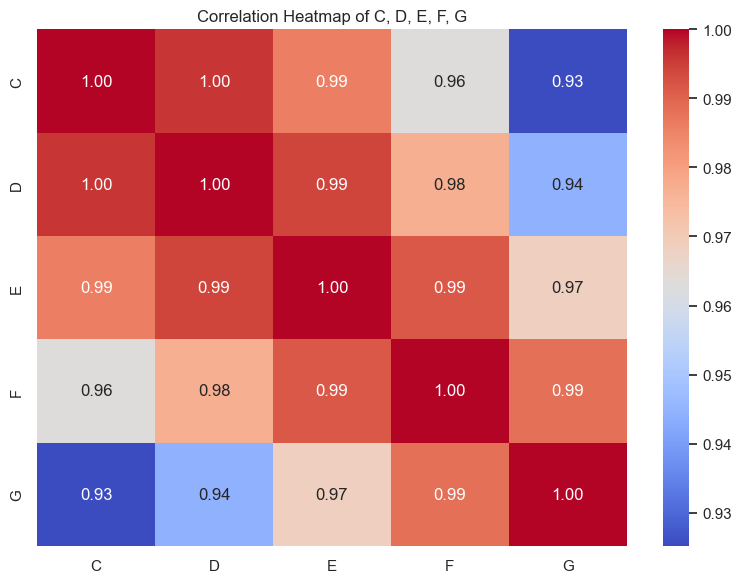

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(df_raw[['C', 'D', 'E', 'F', 'G']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of C, D, E, F, G')
plt.tight_layout()
plt.show()

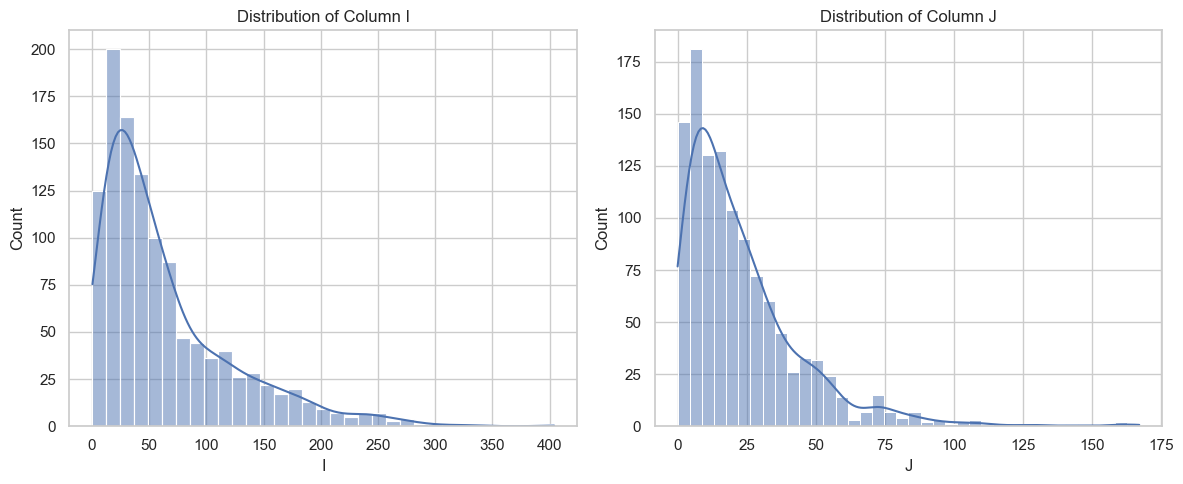

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df_raw['I'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Column I')

sns.histplot(df_raw['J'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Column J')

plt.tight_layout()
plt.show()

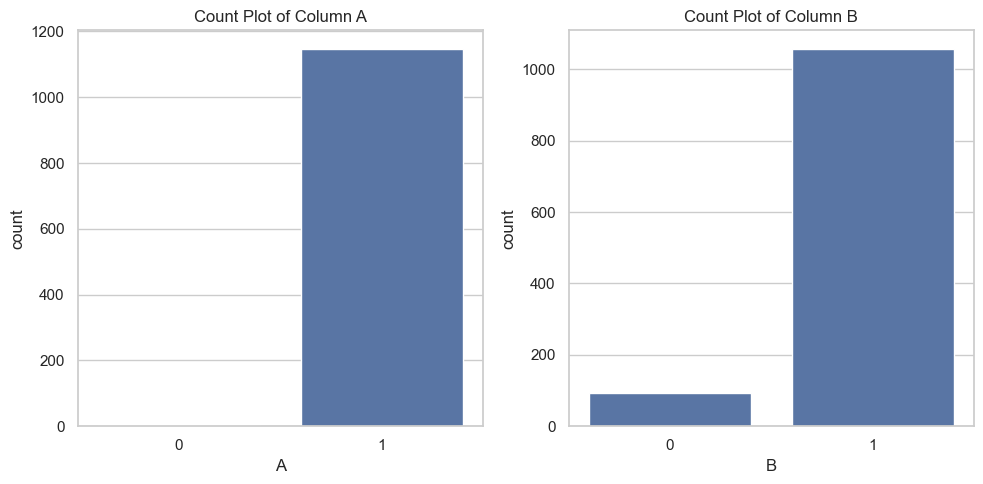

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.countplot(x=df_raw['A'], ax=axes[0])
axes[0].set_title('Count Plot of Column A')

sns.countplot(x=df_raw['B'], ax=axes[1])
axes[1].set_title('Count Plot of Column B')

plt.tight_layout()
plt.show()

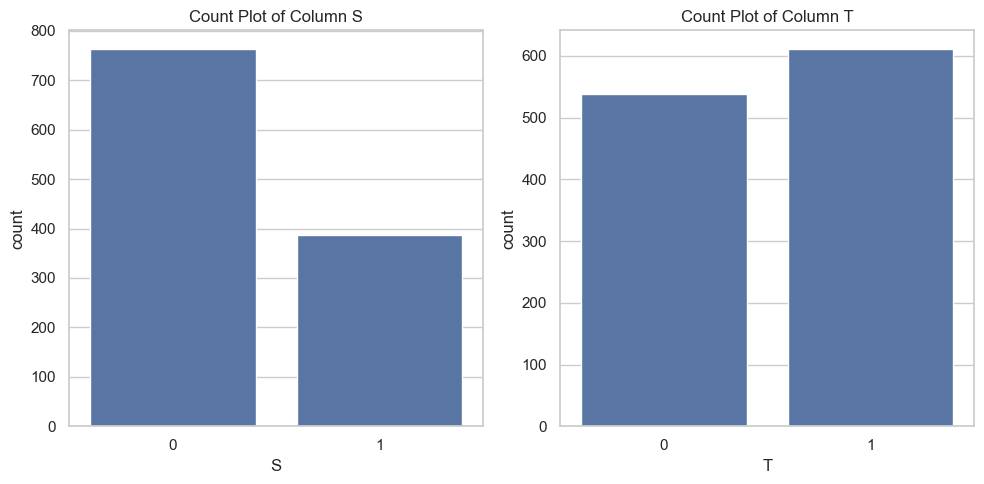

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.countplot(x=df_raw['S'], ax=axes[0])
axes[0].set_title('Count Plot of Column S')

sns.countplot(x=df_raw['T'], ax=axes[1])
axes[1].set_title('Count Plot of Column T')

plt.tight_layout()
plt.show()